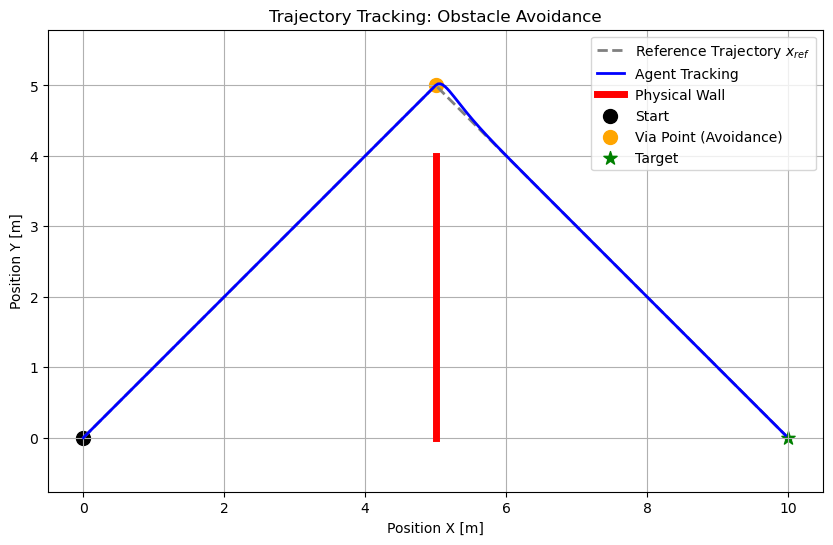

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import place_poles

# ============================================================================
# 1. SYSTEM DEFINITION (2D Planar Double Integrator)
# ============================================================================
Ts = 0.05
sim_steps = 300  # Prodloužíme simulaci pro delší let (15 sekund)

A = np.array([
    [1.0, 0.0,  Ts, 0.0],
    [0.0, 1.0, 0.0,  Ts],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0]
])

B = np.array([
    [0.5 * Ts**2, 0.0],
    [0.0, 0.5 * Ts**2],
    [Ts,          0.0],
    [0.0,         Ts]
])

# ============================================================================
# 2. EXPERT SYNTHESIS (Pole Placement)
# ============================================================================
desired_poles = np.array([0.80, 0.81, 0.82, 0.83])
place_obj = place_poles(A, B, desired_poles)
K_expert_np = place_obj.gain_matrix

# ============================================================================
# 3. MANUAL TRAJECTORY GENERATION (Obstacle Avoidance)
# ============================================================================
# Wall parameters: x = 5.0, spanning y from 0.0 to 4.0
start_pos = np.array([0.0, 0.0])
via_pos = np.array([5.0, 5.0])    # Fly over the wall
target_pos = np.array([10.0, 0.0])

x_ref = np.zeros((sim_steps, 4)) # [p_x, p_y, v_x, v_y]

# We will divide the flight into two segments
steps_seg1 = sim_steps // 2
steps_seg2 = sim_steps - steps_seg1

# Segment 1: Start -> Via-point
time_seg1 = steps_seg1 * Ts
vel_seg1 = (via_pos - start_pos) / time_seg1

for k in range(steps_seg1):
    t = k * Ts
    x_ref[k, 0:2] = start_pos + vel_seg1 * t
    x_ref[k, 2:4] = vel_seg1

# Segment 2: Via-point -> Target
time_seg2 = steps_seg2 * Ts
vel_seg2 = (target_pos - via_pos) / time_seg2

for k in range(steps_seg2):
    t = k * Ts
    idx = steps_seg1 + k
    x_ref[idx, 0:2] = via_pos + vel_seg2 * t
    x_ref[idx, 2:4] = vel_seg2

# ============================================================================
# 4. CLOSED-LOOP TRACKING SIMULATION
# ============================================================================
x_expert = np.array([0.0, 0.0, 0.0, 0.0]) # Initial state

traj_agent = np.zeros((sim_steps, 4))

for k in range(sim_steps):
    traj_agent[k, :] = x_expert
    
    # Calculate state error
    e_k = x_expert - x_ref[k, :]
    
    # State feedback tracking law
    u_k = -K_expert_np @ e_k
    
    # Environment step
    x_expert = A @ x_expert + B @ u_k

# ============================================================================
# 5. VISUALIZATION
# ============================================================================
plt.figure(figsize=(10, 6))

# Plot Reference and Agent trajectories
plt.plot(x_ref[:, 0], x_ref[:, 1], label='Reference Trajectory $x_{ref}$', linestyle='--', color='gray', linewidth=2)
plt.plot(traj_agent[:, 0], traj_agent[:, 1], label='Agent Tracking', color='blue', linewidth=2)

# Plot the physical wall
plt.plot([5.0, 5.0], [0.0, 4.0], color='red', linewidth=5, label='Physical Wall')

plt.scatter(start_pos[0], start_pos[1], color='black', s=100, label='Start')
plt.scatter(via_pos[0], via_pos[1], color='orange', s=100, label='Via Point (Avoidance)')
plt.scatter(target_pos[0], target_pos[1], color='green', s=100, marker='*', label='Target')

plt.title('Trajectory Tracking: Obstacle Avoidance')
plt.xlabel('Position X [m]')
plt.ylabel('Position Y [m]')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

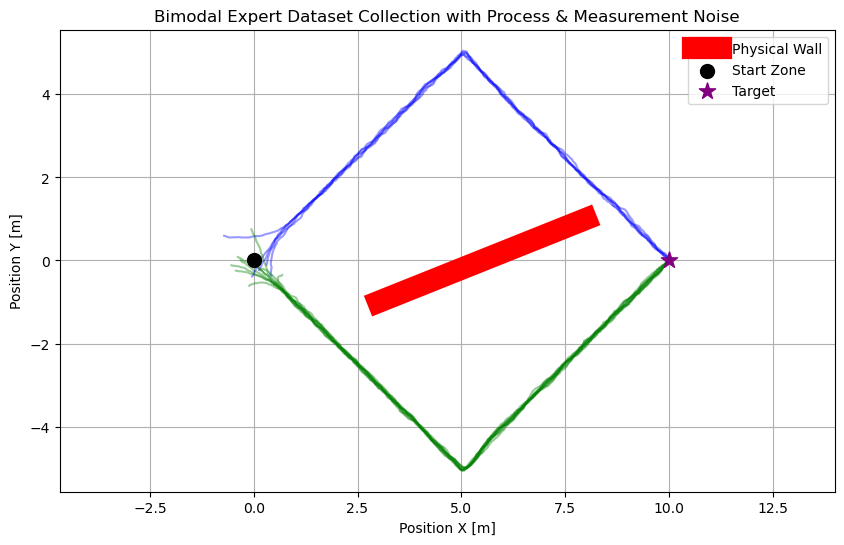

Dataset generated. Observations shape: torch.Size([150000, 4]), Actions shape: torch.Size([150000, 2])


In [2]:
def generate_bimodal_dataset(num_episodes=50, sim_steps=300):
    # ========================================================================
    # 1. SYSTEM DEFINITION & EXPERT SYNTHESIS
    # ========================================================================
    Ts = 0.05
    A = np.array([
        [1.0, 0.0,  Ts, 0.0],
        [0.0, 1.0, 0.0,  Ts],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0]
    ])
    B = np.array([
        [0.5 * Ts**2, 0.0],
        [0.0, 0.5 * Ts**2],
        [Ts,          0.0],
        [0.0,         Ts]
    ])

    desired_poles = np.array([0.80, 0.81, 0.82, 0.83])
    place_obj = place_poles(A, B, desired_poles)
    K_expert = place_obj.gain_matrix

    # ========================================================================
    # 2. NOISE COVARIANCE MATRICES
    # ========================================================================
    # Process noise covariance (e.g., wind turbulence affecting velocities)
    W_cov = np.diag([1e-4, 1e-4, 2e-3, 2e-3])
    
    # Measurement noise covariance (e.g., GPS and IMU inaccuracies)
    V_cov = np.diag([1e-3, 1e-3, 5e-3, 5e-3])
    
    # Initial state covariance
    X0_cov = np.diag([0.2, 0.2, 0.01, 0.01])

    # ========================================================================
    # 3. DATASET ALLOCATION
    # ========================================================================
    dataset_observations = []
    dataset_actions = []

    plt.figure(figsize=(10, 6))

    # ========================================================================
    # 4. EPISODIC SIMULATION LOOP
    # ========================================================================
    for ep in range(num_episodes):
        # Stochastic Decision: Fly OVER (5.0) or UNDER (-5.0) the wall
        direction = 1.0 if np.random.rand() > 0.5 else -1.0
        
        start_pos = np.array([0.0, 0.0])
        via_pos = np.array([5.0, 5.0 * direction]) 
        target_pos = np.array([10.0, 0.0])

        # Generate Reference Trajectory for this specific episode
        x_ref = np.zeros((sim_steps, 4))
        steps_seg1 = sim_steps // 2
        steps_seg2 = sim_steps - steps_seg1

        vel_seg1 = (via_pos - start_pos) / (steps_seg1 * Ts)
        for k in range(steps_seg1):
            x_ref[k, 0:2] = start_pos + vel_seg1 * (k * Ts)
            x_ref[k, 2:4] = vel_seg1

        vel_seg2 = (target_pos - via_pos) / (steps_seg2 * Ts)
        for k in range(steps_seg2):
            idx = steps_seg1 + k
            x_ref[idx, 0:2] = via_pos + vel_seg2 * (k * Ts)
            x_ref[idx, 2:4] = vel_seg2

        # Initialize physical state with Gaussian noise
        x_expert = np.random.multivariate_normal([0.0, 0.0, 0.0, 0.0], X0_cov)
        
        traj_x = []
        traj_y = []

        # Closed-loop tracking under uncertainty
        for k in range(sim_steps):
            # A. Sensor Measurement (y_k = x_k + v_k)
            v_k = np.random.multivariate_normal(np.zeros(4), V_cov)
            y_k = x_expert + v_k
            
            # B. Expert Control Law based on MEASUREMENT
            e_k = y_k - x_ref[k, :]
            u_k = -K_expert @ e_k
            
            # C. Log data for Imitation Learning
            dataset_observations.append(y_k)
            dataset_actions.append(u_k)
            
            # D. Environment Dynamics (x_{k+1} = A*x_k + B*u_k + w_k)
            w_k = np.random.multivariate_normal(np.zeros(4), W_cov)
            x_expert = A @ x_expert + B @ u_k + w_k
            
            traj_x.append(x_expert[0])
            traj_y.append(x_expert[1])

        # Plot only a subset of trajectories to keep the graph readable
        if ep < 15:
            color = 'blue' if direction > 0 else 'green'
            plt.plot(traj_x, traj_y, color=color, alpha=0.4, linewidth=1.5)

    # ========================================================================
    # 5. VISUALIZATION FINISHING
    # ========================================================================
    plt.plot([3.0, 8.0], [-1.0, 1.0], color='red', linewidth=16, label='Physical Wall')
    plt.scatter(0, 0, color='black', s=100, zorder=5, label='Start Zone')
    plt.scatter(10, 0, color='purple', marker='*', s=150, zorder=5, label='Target')
    
    plt.title('Bimodal Expert Dataset Collection with Process & Measurement Noise')
    plt.xlabel('Position X [m]')
    plt.ylabel('Position Y [m]')
    plt.grid(True)
    plt.axis('equal')
    plt.legend()
    plt.show()

    # Convert to PyTorch tensors for neural network training
    obs_tensor = torch.tensor(np.array(dataset_observations), dtype=torch.float32)
    act_tensor = torch.tensor(np.array(dataset_actions), dtype=torch.float32)
    
    return obs_tensor, act_tensor

# Execute the generator
obs_data, act_data = generate_bimodal_dataset(num_episodes=500, sim_steps=300)
print(f"Dataset generated. Observations shape: {obs_data.shape}, Actions shape: {act_data.shape}")

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================================
# 1. PLANAR DIFFUSION POLICY NETWORK
# ============================================================================
class PlanarDiffusionPolicy(nn.Module):
    def __init__(self):
        super(PlanarDiffusionPolicy, self).__init__()
        # Input dim: State (4) + Action (2) + Time (1) = 7
        # Output dim: Predicted Noise (2)
        self.net = nn.Sequential(
            nn.Linear(7, 128),
            nn.Mish(), 
            nn.Linear(128, 128),
            nn.Mish(),
            nn.Linear(128, 2)
        )

    def forward(self, x, a, t_norm):
        # Concatenate State, Action, and Normalized Time
        inputs = torch.cat([x, a, t_norm], dim=1)
        return self.net(inputs)

In [4]:
# ============================================================================
# 2. DIFFUSION SCHEDULE SETUP
# ============================================================================
T_steps = 50
betas = torch.linspace(1e-4, 0.05, T_steps)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Předpokládáme, že obs_data (N, 4) a act_data (N, 2) už máme vygenerované
# z vaší funkce generate_bimodal_dataset.
N_total = obs_data.shape[0]

policy = PlanarDiffusionPolicy()
optimizer = optim.Adam(policy.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [5]:
# ============================================================================
# 3. TRAINING LOOP WITH DATA NORMALIZATION
# ============================================================================
epochs = 10000
batch_size = 256

# Calculate dataset statistics for Z-score normalization
# Adding a small epsilon (1e-6) to prevent division by zero
obs_mean = obs_data.mean(dim=0, keepdim=True)
obs_std = obs_data.std(dim=0, keepdim=True) + 1e-6

act_mean = act_data.mean(dim=0, keepdim=True)
act_std = act_data.std(dim=0, keepdim=True) + 1e-6

print("Observation Mean:", obs_mean.numpy())
print("Action Mean:", act_mean.numpy())

for epoch in range(epochs):
    indices = torch.randint(0, N_total, (batch_size,))
    
    # Normalize states and actions before feeding to the network
    x_batch = (obs_data[indices] - obs_mean) / obs_std
    u_expert_batch = (act_data[indices] - act_mean) / act_std
    
    optimizer.zero_grad()
    
    t = torch.randint(0, T_steps, (batch_size, 1))
    alpha_cumprod_t = alphas_cumprod[t] 
    
    noise = torch.randn_like(u_expert_batch)
    noisy_action = torch.sqrt(alpha_cumprod_t) * u_expert_batch + torch.sqrt(1 - alpha_cumprod_t) * noise
    
    t_norm = (t.float() / T_steps) * 2.0 - 1.0
    
    predicted_noise = policy(x_batch, noisy_action, t_norm)
    loss = criterion(predicted_noise, noise)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

Observation Mean: [[ 4.98084450e+00 -1.20129764e-01  6.65178776e-01  1.58534647e-04]]
Action Mean: [[0.0445781  0.00276592]]
Epoch    0 | Loss: 1.000711


/home/luky/.local/lib/python3.10/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch  500 | Loss: 0.630897
Epoch 1000 | Loss: 0.577495
Epoch 1500 | Loss: 0.523626
Epoch 2000 | Loss: 0.489301
Epoch 2500 | Loss: 0.459785
Epoch 3000 | Loss: 0.437604
Epoch 3500 | Loss: 0.484320
Epoch 4000 | Loss: 0.473011
Epoch 4500 | Loss: 0.510602
Epoch 5000 | Loss: 0.452828
Epoch 5500 | Loss: 0.489199
Epoch 6000 | Loss: 0.518378
Epoch 6500 | Loss: 0.412804
Epoch 7000 | Loss: 0.427901
Epoch 7500 | Loss: 0.445333
Epoch 8000 | Loss: 0.494047
Epoch 8500 | Loss: 0.416900
Epoch 9000 | Loss: 0.444824
Epoch 9500 | Loss: 0.472184


Simulating test episode 1/5...
Simulating test episode 2/5...
Simulating test episode 3/5...
Simulating test episode 4/5...
Simulating test episode 5/5...


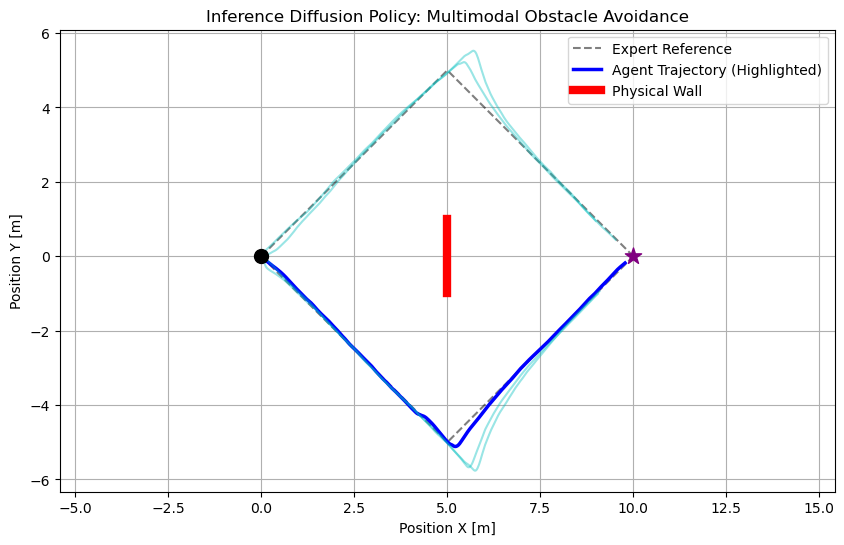


--- TRACKING ERROR ANALYSIS ---
Episode 1: Detected flight DOWN. Average positional error from expert: 0.1895 m
Episode 2: Detected flight UP. Average positional error from expert: 0.8909 m
Episode 3: Detected flight DOWN. Average positional error from expert: 0.7355 m
Episode 4: Detected flight DOWN. Average positional error from expert: 0.8477 m
Episode 5: Detected flight UP. Average positional error from expert: 0.3566 m


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 4. INFERENCE FUNCTION WITH NORMALIZATION
# ============================================================================
def sample_diffusion_action_2d(state_np, policy_net, T_steps, alphas, alphas_cumprod, betas, 
                               obs_mean, obs_std, act_mean, act_std):
    """
    Simulates the closed-loop reverse SDE to obtain 1 action vector.
    """
    policy_net.eval()
    with torch.no_grad():
        # CRITICAL FIX: Normalize the incoming physical state
        state_tensor = torch.tensor(state_np, dtype=torch.float32).unsqueeze(0)
        x_k = (state_tensor - obs_mean) / obs_std
        
        # Start from pure standard Gaussian noise
        a_k = torch.randn(1, 2) 
        
        for k in reversed(range(T_steps)):
            t_tensor = torch.full((1, 1), k)
            t_norm = (t_tensor.float() / T_steps) * 2.0 - 1.0
            
            pred_noise = policy_net(x_k, a_k, t_norm)
            
            alpha_k = alphas[k]
            alpha_cumprod_k = alphas_cumprod[k]
            
            # Euler-Maruyama step
            a_k = (1 / torch.sqrt(alpha_k)) * (a_k - ((1 - alpha_k) / torch.sqrt(1 - alpha_cumprod_k)) * pred_noise)
            
            if k > 0:
                z = torch.randn_like(a_k)
                a_k = a_k + torch.sqrt(betas[k]) * z
                
        # CRITICAL FIX: Denormalize the action back to physical scale before applying to the drone
        a_k_physical = a_k * act_std + act_mean
        
    return a_k_physical.numpy().flatten()

# ============================================================================
# 2. EXPERT REFERENCE GENERATOR FOR ERROR EVALUATION
# ============================================================================
def get_expert_reference(direction_sign, sim_steps, Ts):
    x_ref = np.zeros((sim_steps, 4))
    start_pos = np.array([0.0, 0.0])
    via_pos = np.array([5.0, 5.0 * direction_sign]) 
    target_pos = np.array([10.0, 0.0])

    steps_seg1 = sim_steps // 2
    steps_seg2 = sim_steps - steps_seg1

    vel_seg1 = (via_pos - start_pos) / (steps_seg1 * Ts)
    for k in range(steps_seg1):
        x_ref[k, 0:2] = start_pos + vel_seg1 * (k * Ts)

    vel_seg2 = (target_pos - via_pos) / (steps_seg2 * Ts)
    for k in range(steps_seg2):
        idx = steps_seg1 + k
        x_ref[idx, 0:2] = via_pos + vel_seg2 * (k * Ts)
        
    return x_ref

# ============================================================================
# 3. TEST LOOP (Closed-Loop) AND ERROR CALCULATION
# ============================================================================
num_test_episodes = 5
sim_steps = 300
Ts = 0.05

trajectories = []
errors = []

for ep in range(num_test_episodes):
    x_agent = np.array([0.0, 0.0, 0.0, 0.0]) # Start at origin (ideal test conditions)
    traj = np.zeros((sim_steps, 4))
    
    print(f"Simulating test episode {ep+1}/{num_test_episodes}...")
    for k in range(sim_steps):
        traj[k, :] = x_agent
        
        # Get action from diffusion model (FIXED ARGUMENTS HERE)
        u_agt = sample_diffusion_action_2d(x_agent, policy, T_steps, alphas, alphas_cumprod, betas, obs_mean, obs_std, act_mean, act_std)
        
        # Environment physical step
        x_agent = A @ x_agent + B @ u_agt
        
    trajectories.append(traj)
    
    # Classify agent intent (Flew UP or DOWN?)
    # Evaluate y-position when passing the wall (around step 150)
    intent_sign = 1.0 if traj[sim_steps//2, 1] > 0 else -1.0
    
    # Get corresponding expert trajectory for comparison
    x_ref_true = get_expert_reference(intent_sign, sim_steps, Ts)
    
    # Calculate Mean Squared Error (MSE) of position
    pos_error = np.mean(np.linalg.norm(traj[:, 0:2] - x_ref_true[:, 0:2], axis=1))
    errors.append((intent_sign, pos_error))

# ============================================================================
# 4. PLOTTING AND REPORT
# ============================================================================
plt.figure(figsize=(10, 6))

# Plot expert references in gray
x_ref_up = get_expert_reference(1.0, sim_steps, Ts)
x_ref_down = get_expert_reference(-1.0, sim_steps, Ts)
plt.plot(x_ref_up[:, 0], x_ref_up[:, 1], 'k--', alpha=0.5, label='Expert Reference')
plt.plot(x_ref_down[:, 0], x_ref_down[:, 1], 'k--', alpha=0.5)

# Plot agent trajectories (gray in background, highlight the first one)
for i, traj in enumerate(trajectories):
    if i == 0:
        plt.plot(traj[:, 0], traj[:, 1], 'b-', linewidth=2.5, label='Agent Trajectory (Highlighted)')
    else:
        plt.plot(traj[:, 0], traj[:, 1], 'c-', alpha=0.4)

plt.plot([5.0, 5.0], [-1.0, 1.0], color='red', linewidth=6, label='Physical Wall')
plt.scatter(0, 0, color='black', s=100, zorder=5)
plt.scatter(10, 0, color='purple', marker='*', s=150, zorder=5)

plt.title('Inference Diffusion Policy: Multimodal Obstacle Avoidance')
plt.xlabel('Position X [m]')
plt.ylabel('Position Y [m]')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- TRACKING ERROR ANALYSIS ---")
for i, (intent, err) in enumerate(errors):
    mode_str = "UP" if intent > 0 else "DOWN"
    print(f"Episode {i+1}: Detected flight {mode_str}. Average positional error from expert: {err:.4f} m")

# Human gated DAgger

In [7]:
import torch
import numpy as np

# ============================================================================
# 1. HG-DAGGER SETTINGS & SIMULATED HUMAN INTERVENTION
# ============================================================================
dagger_episodes = 10
intervention_threshold = 0.5  # Meters (Max allowed deviation before human takes over)

new_observations = []
new_actions = []

print("Starting HG-DAgger data collection...")

policy.eval()

for ep in range(dagger_episodes):
    # Stochastic Decision: Fly OVER (1.0) or UNDER (-1.0) the wall
    direction_sign = 1.0 if np.random.rand() > 0.5 else -1.0
    
    # Generate Reference Trajectory for this episode
    x_ref = get_expert_reference(direction_sign, sim_steps, Ts)
    
    # Start at origin
    x_agent = np.array([0.0, 0.0, 0.0, 0.0])
    
    human_in_control = False
    
    print(f"  DAgger Rollout {ep+1}/{dagger_episodes} (Direction: {direction_sign})")
    
    for k in range(sim_steps):
        # Calculate current error from ideal trajectory
        current_error = np.linalg.norm(x_agent[0:2] - x_ref[k, 0:2])
        
        # Human-Gating Logic (Step 2 on slide)
        if not human_in_control and current_error > intervention_threshold:
            human_in_control = True
            print(f"    -> Intervention triggered at step {k} (Error: {current_error:.2f}m)")
        
        if human_in_control:
            # EXPERT TAKES OVER (Step 3 on slide: Expert provides demonstration)
            e_k = x_agent - x_ref[k, :]
            u_applied = -K_expert_np @ e_k
            
            # Save corrective data
            new_observations.append(x_agent.copy())
            new_actions.append(u_applied.copy())
        else:
            # AGENT DRIVES (Step 1 on slide: Roll-out learned policy)
            u_applied = sample_diffusion_action_2d(
                x_agent, policy, T_steps, alphas, alphas_cumprod, betas, 
                obs_mean, obs_std, act_mean, act_std
            )
        
        # Environment dynamics
        x_agent = A @ x_agent + B @ u_applied

print(f"\nCollected {len(new_observations)} corrective samples.")

# ============================================================================
# 2. DATASET AGGREGATION (Step 4 on slide)
# ============================================================================
if len(new_observations) > 0:
    # Convert new data to tensors
    new_obs_tensor = torch.tensor(np.array(new_observations), dtype=torch.float32)
    new_act_tensor = torch.tensor(np.array(new_actions), dtype=torch.float32)
    
    # Aggregate with existing dataset D <- D U {(s'_i, a^*_i)}
    obs_data = torch.cat([obs_data, new_obs_tensor], dim=0)
    act_data = torch.cat([act_data, new_act_tensor], dim=0)
    
    N_total = obs_data.shape[0]
    print(f"Dataset aggregated. New size: {N_total} samples.")
    
    # CRITICAL: Recalculate Z-score normalization statistics for the expanded dataset
    obs_mean = obs_data.mean(dim=0, keepdim=True)
    obs_std = obs_data.std(dim=0, keepdim=True) + 1e-6
    act_mean = act_data.mean(dim=0, keepdim=True)
    act_std = act_data.std(dim=0, keepdim=True) + 1e-6

# ============================================================================
# 3. POLICY FINE-TUNING (Step 5 on slide: Update policy)
# ============================================================================
print("\nStarting HG-DAgger Fine-Tuning...")

policy.train()
dagger_epochs = 3000  # We don't need 10000 again, just fine-tuning

for epoch in range(dagger_epochs):
    indices = torch.randint(0, N_total, (batch_size,))
    
    x_batch = (obs_data[indices] - obs_mean) / obs_std
    u_expert_batch = (act_data[indices] - act_mean) / act_std
    
    optimizer.zero_grad()
    
    t = torch.randint(0, T_steps, (batch_size, 1))
    alpha_cumprod_t = alphas_cumprod[t] 
    
    noise = torch.randn_like(u_expert_batch)
    noisy_action = torch.sqrt(alpha_cumprod_t) * u_expert_batch + torch.sqrt(1 - alpha_cumprod_t) * noise
    
    t_norm = (t.float() / T_steps) * 2.0 - 1.0
    
    predicted_noise = policy(x_batch, noisy_action, t_norm)
    loss = criterion(predicted_noise, noise)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 500 == 0:
        print(f"DAgger Epoch {epoch:4d} | Loss: {loss.item():.6f}")

print("HG-DAgger Fine-Tuning Complete.")

Starting HG-DAgger data collection...
  DAgger Rollout 1/10 (Direction: 1.0)
    -> Intervention triggered at step 11 (Error: 0.51m)
  DAgger Rollout 2/10 (Direction: 1.0)
    -> Intervention triggered at step 162 (Error: 0.55m)
  DAgger Rollout 3/10 (Direction: 1.0)
    -> Intervention triggered at step 12 (Error: 0.56m)
  DAgger Rollout 4/10 (Direction: 1.0)
    -> Intervention triggered at step 9 (Error: 0.54m)
  DAgger Rollout 5/10 (Direction: -1.0)
  DAgger Rollout 6/10 (Direction: -1.0)
    -> Intervention triggered at step 160 (Error: 0.52m)
  DAgger Rollout 7/10 (Direction: 1.0)
    -> Intervention triggered at step 160 (Error: 0.54m)
  DAgger Rollout 8/10 (Direction: 1.0)
    -> Intervention triggered at step 13 (Error: 0.53m)
  DAgger Rollout 9/10 (Direction: -1.0)
    -> Intervention triggered at step 160 (Error: 0.51m)
  DAgger Rollout 10/10 (Direction: 1.0)
    -> Intervention triggered at step 134 (Error: 0.50m)

Collected 1879 corrective samples.
Dataset aggregated. New 

Starting Evaluation of HG-DAgger Fine-Tuned Policy...
  Simulating test episode 1/5...
  Simulating test episode 2/5...
  Simulating test episode 3/5...
  Simulating test episode 4/5...
  Simulating test episode 5/5...


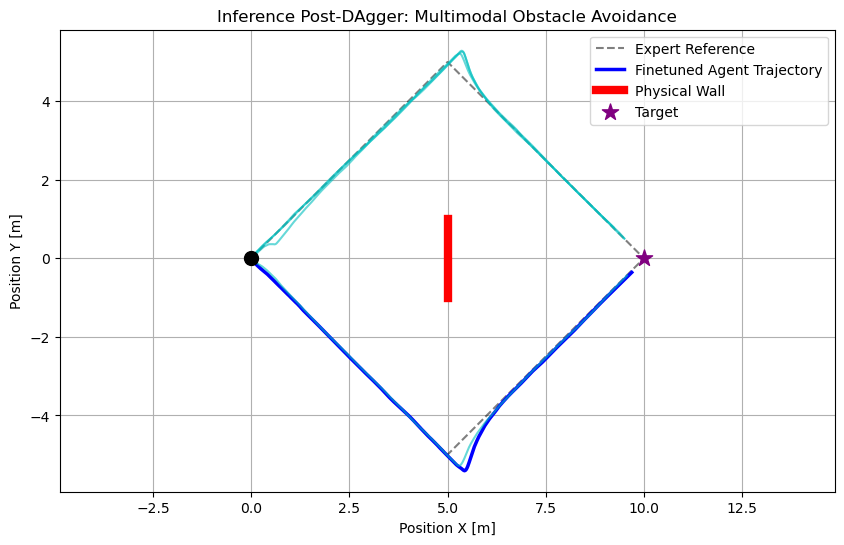


--- TRACKING ERROR ANALYSIS (POST-DAGGER) ---
Episode 1: Detected flight DOWN. Average positional error from expert: 0.2923 m
Episode 2: Detected flight DOWN. Average positional error from expert: 0.4965 m
Episode 3: Detected flight UP. Average positional error from expert: 0.4181 m
Episode 4: Detected flight UP. Average positional error from expert: 0.7841 m
Episode 5: Detected flight UP. Average positional error from expert: 0.4058 m


In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 1. TEST LOOP (Closed-Loop) FOR FINETUNED MODEL
# ============================================================================
print("Starting Evaluation of HG-DAgger Fine-Tuned Policy...")

num_test_episodes = 5
sim_steps = 300
Ts = 0.05

trajectories = []
errors = []

# Ensure the policy is in evaluation mode
policy.eval()

for ep in range(num_test_episodes):
    # Start at origin (ideal test conditions)
    x_agent = np.array([0.0, 0.0, 0.0, 0.0]) 
    traj = np.zeros((sim_steps, 4))
    
    print(f"  Simulating test episode {ep+1}/{num_test_episodes}...")
    for k in range(sim_steps):
        traj[k, :] = x_agent
        
        # Get action from the FINETUNED diffusion model
        # Note: obs_mean, obs_std, act_mean, act_std must be the updated ones from the DAgger step
        u_agt = sample_diffusion_action_2d(
            x_agent, policy, T_steps, alphas, alphas_cumprod, betas, 
            obs_mean, obs_std, act_mean, act_std
        )
        
        # Environment physical step
        x_agent = A @ x_agent + B @ u_agt
        
    trajectories.append(traj)
    
    # Classify agent intent (Flew UP or DOWN?)
    # Evaluate y-position when passing the wall (around step 150)
    intent_sign = 1.0 if traj[sim_steps//2, 1] > 0 else -1.0
    
    # Get corresponding expert trajectory for comparison
    x_ref_true = get_expert_reference(intent_sign, sim_steps, Ts)
    
    # Calculate Mean Squared Error (MSE) of position relative to the expert
    pos_error = np.mean(np.linalg.norm(traj[:, 0:2] - x_ref_true[:, 0:2], axis=1))
    errors.append((intent_sign, pos_error))

# ============================================================================
# 2. PLOTTING AND REPORT
# ============================================================================
plt.figure(figsize=(10, 6))

# Plot expert references in gray
x_ref_up = get_expert_reference(1.0, sim_steps, Ts)
x_ref_down = get_expert_reference(-1.0, sim_steps, Ts)
plt.plot(x_ref_up[:, 0], x_ref_up[:, 1], 'k--', alpha=0.5, label='Expert Reference')
plt.plot(x_ref_down[:, 0], x_ref_down[:, 1], 'k--', alpha=0.5)

# Plot agent trajectories (gray in background, highlight the first one)
for i, traj in enumerate(trajectories):
    if i == 0:
        plt.plot(traj[:, 0], traj[:, 1], 'b-', linewidth=2.5, label='Finetuned Agent Trajectory')
    else:
        plt.plot(traj[:, 0], traj[:, 1], 'c-', alpha=0.6)

# Plot environment elements
plt.plot([5.0, 5.0], [-1.0, 1.0], color='red', linewidth=6, label='Physical Wall')
plt.scatter(0, 0, color='black', s=100, zorder=5)
plt.scatter(10, 0, color='purple', marker='*', s=150, zorder=5, label='Target')

plt.title('Inference Post-DAgger: Multimodal Obstacle Avoidance')
plt.xlabel('Position X [m]')
plt.ylabel('Position Y [m]')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- TRACKING ERROR ANALYSIS (POST-DAGGER) ---")
for i, (intent, err) in enumerate(errors):
    mode_str = "UP" if intent > 0 else "DOWN"
    print(f"Episode {i+1}: Detected flight {mode_str}. Average positional error from expert: {err:.4f} m")